# 01 — Data Exploration: Medical Appointment No-Shows

**Project:** Patient Access & No-Show Automation Platform

This notebook explores the raw appointment dataset (Kaggle *Medical Appointment
No Shows* schema). The goal is to understand which factors correlate with
missed appointments before building features and a prediction model.

> If the real Kaggle file is not present, `etl/load_raw_data.py` generates a
> synthetic dataset with the same columns and realistic behavioral patterns,
> so this notebook runs either way.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 30)
RAW = Path("../data/raw/appointments_raw.csv")
df = pd.read_csv(RAW)
print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
df.head()

Rows: 32,000   Columns: 14


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,1.403923e+10,5628929,F,2025-08-16T09:58:49Z,2025-09-12T00:00:00Z,45,GOIABEIRAS,0,0,0,0,0,1,No
1,2.877808e+10,5627567,F,2025-09-05T10:22:26Z,2025-09-12T00:00:00Z,17,BONFIM,0,0,0,0,1,1,No
2,5.193866e+10,5619190,F,2025-09-08T09:03:30Z,2025-09-12T00:00:00Z,12,JOANA DARC,0,0,0,0,0,1,No
3,4.964554e+10,5627204,M,2025-09-04T07:59:35Z,2025-09-12T00:00:00Z,98,FORTE SAO JOAO,0,0,1,0,0,1,No
4,3.538890e+10,5628478,M,2025-08-15T10:17:56Z,2025-09-12T00:00:00Z,24,REDENCAO,0,0,0,0,0,1,No


## Column overview and data quality

In [2]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulls": df.isna().sum(),
    "unique": df.nunique(),
})
summary

,dtype,nulls,unique
PatientId,float64,0,5695
AppointmentID,int64,0,32000
Gender,object,0,2
ScheduledDay,object,0,31963
AppointmentDay,object,0,213
Age,int64,0,96
Neighbourhood,object,0,40
Scholarship,int64,0,2
Hipertension,int64,0,2
Diabetes,int64,0,2


## Target distribution — how big is the no-show problem?

In [3]:
no_show = df["No-show"].astype(str).str.strip().str.lower().eq("yes")
rate = no_show.mean()
print(f"No-show rate: {rate:.1%}  ({no_show.sum():,} of {len(df):,} appointments)")

No-show rate: 19.9%  (6,381 of 32,000 appointments)


Roughly **1 in 5 appointments is missed**. At a typical fully-loaded cost of
$150–$200 per unused slot, this is the core business problem the platform
attacks.

## No-show rate by patient age

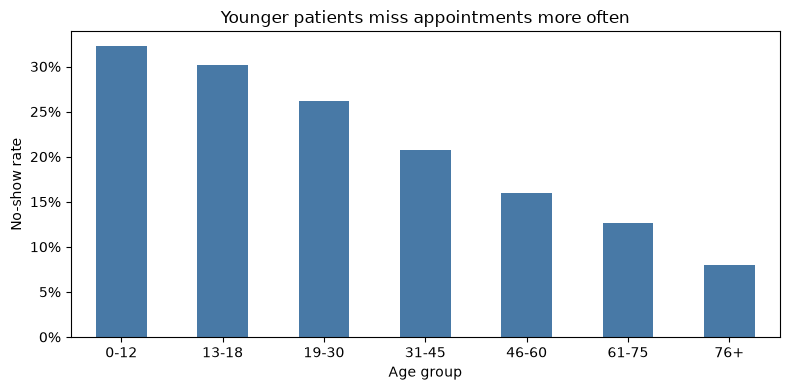

In [4]:
tmp = df.assign(no_show=no_show)
tmp["age_group"] = pd.cut(tmp["Age"], [0, 12, 18, 30, 45, 60, 75, 100],
                          labels=["0-12", "13-18", "19-30", "31-45", "46-60", "61-75", "76+"],
                          include_lowest=True)
by_age = tmp.groupby("age_group", observed=True)["no_show"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
by_age.plot(kind="bar", ax=ax, color="#4879A6")
ax.set_ylabel("No-show rate"); ax.set_xlabel("Age group")
ax.set_title("Younger patients miss appointments more often")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## No-show rate by scheduling lead time

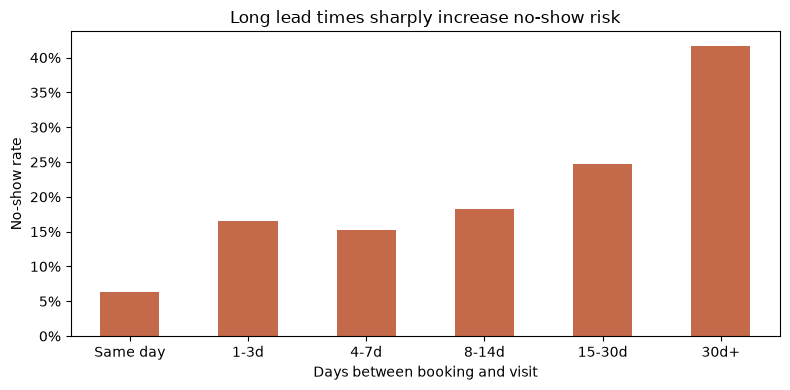

In [5]:
lead = (pd.to_datetime(tmp["AppointmentDay"], utc=True).dt.normalize()
        - pd.to_datetime(tmp["ScheduledDay"], utc=True).dt.normalize()).dt.days
tmp["lead_bucket"] = pd.cut(lead, [-1, 0, 3, 7, 14, 30, 120],
                            labels=["Same day", "1-3d", "4-7d", "8-14d", "15-30d", "30d+"])
by_lead = tmp.groupby("lead_bucket", observed=True)["no_show"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
by_lead.plot(kind="bar", ax=ax, color="#C46A4A")
ax.set_ylabel("No-show rate"); ax.set_xlabel("Days between booking and visit")
ax.set_title("Long lead times sharply increase no-show risk")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## Do SMS reminders help?

In [6]:
by_sms = tmp.groupby("SMS_received")["no_show"].agg(["mean", "count"])
by_sms.index = ["No SMS", "SMS sent"]
by_sms.columns = ["no_show_rate", "appointments"]
by_sms

,no_show_rate,appointments
No SMS,0.205064,17853
SMS sent,0.192267,14147


Note: raw SMS comparisons are confounded — reminders are only sent for
appointments booked several days ahead, which are *inherently riskier*. The
model handles this by using SMS and lead time together.

## No-show rate by day of week

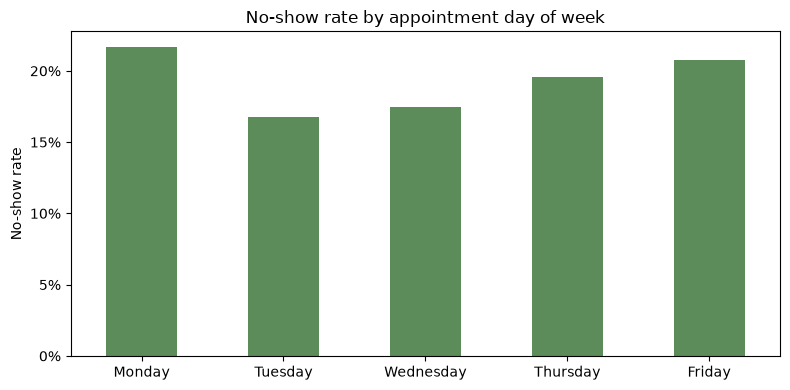

In [7]:
tmp["weekday"] = pd.to_datetime(tmp["AppointmentDay"], utc=True).dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
by_dow = tmp.groupby("weekday")["no_show"].mean().reindex([d for d in order if d in set(tmp['weekday'])])

fig, ax = plt.subplots(figsize=(8, 4))
by_dow.plot(kind="bar", ax=ax, color="#5B8C5A")
ax.set_ylabel("No-show rate"); ax.set_xlabel("")
ax.set_title("No-show rate by appointment day of week")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## Key takeaways

1. **Lead time is the strongest single driver** — appointments booked weeks in
   advance fail far more often than same-week bookings.
2. **Younger adults are the highest-risk age band**; seniors show up reliably.
3. **Reminder effects are confounded with lead time** and need modeling, not
   raw comparison.
4. Chronic-condition flags and social indicators (scholarship) carry modest
   signal — useful in combination.

These findings shape the feature engineering in notebook 02.